# Size-Sweep Trend Analysis

Reads the timestamped per-day CSV written by `size_sweep.py` (`size_sweep_daily_<stamp>.csv`) and shows whether each clip-size config's profitability is **steady, eroding, or expanding** over the 207 days — plus the capacity summary (P&L and per-fill quality vs clip size).

**Auto-loads the most recent** `size_sweep_daily_*.csv` in the Results folder, so no filename editing. Just Run All.

In [1]:
# ---- imports + locate the newest size-sweep CSV ----
# pathlib for filesystem globbing
from pathlib import Path
# dataframes
import pandas as pd
# numeric
import numpy as np
# plotting (charts render inline in the notebook)
import matplotlib.pyplot as plt
# render figures inside the notebook
%matplotlib inline

# the Results folder where size_sweep.py writes its timestamped CSV
RESULTS = Path('/Users/shazzak/Capital Stake - Results')
# find every size-sweep daily CSV
cands = sorted(RESULTS.glob('size_sweep_daily_*.csv'))
# fail loudly if none exist yet (run size_sweep.py first)
assert cands, f'no size_sweep_daily_*.csv in {RESULTS} -- run size_sweep.py first'
# the most recent one (timestamp sorts lexically = chronologically)
CSV = cands[-1]
# load it
df = pd.read_csv(CSV)
# parse the date column to real datetimes for time-axis plotting
df['date'] = pd.to_datetime(df['date'])
# show what we loaded
print(f'loaded {CSV.name}')
print(f'rows: {len(df):,}  |  days: {df.date.nunique()}  |  symbols: {sorted(df.symbol.unique())}')
print(f'configs: {sorted(df.config.unique())}')
df.head()

loaded size_sweep_daily_20260818_0011.csv
rows: 1,260  |  days: 60  |  symbols: ['PACE', 'PPL', 'UBL']
configs: ['0.50x_med', '0.75x_med', '1.00x_med', '1.25x_med', '1.50x_med', '2.00x_med', 'fixed50']


,date,symbol,config,clip_sh,med_trade_sh,adv_pkr,fills,pnl_pkr,net_bps,fill_notional_pkr,participation_pct,top_bid_sh,top_ask_sh
0,2025-09-15,PPL,fixed50,50,200.0,1.815078e+09,45,190.64,2.089,337179.0,0.0186,501.0,800.0
1,2025-09-15,PPL,0.50x_med,100,200.0,1.815078e+09,54,338.17,2.600,740528.0,0.0408,501.0,800.0
2,2025-09-15,PPL,0.75x_med,150,200.0,1.815078e+09,57,511.15,2.537,1099336.0,0.0606,501.0,800.0
3,2025-09-15,PPL,1.00x_med,200,200.0,1.815078e+09,59,662.03,2.586,1451114.0,0.0799,501.0,800.0
4,2025-09-15,PPL,1.25x_med,250,200.0,1.815078e+09,64,659.56,2.796,1759533.0,0.0969,501.0,800.0


## 1. Capacity summary — P&L and per-fill quality vs clip size

The core sweep read. For each symbol, as the clip grows: does total P&L rise while **`net_bps`** (per-fill quality) holds? Flat `net_bps` with rising P&L = room to size up. Falling `net_bps` = the per-fill edge is eroding under size (the ceiling).

*Caveat: the backtest models queue position but not market impact or size-dependent adverse selection, so a clean `net_bps` at 2x is a lower bound on the true cost, not proof 2x is safe.*

In [2]:
# ---- per-(symbol, config) totals table ----
# config order for readable sorting (control first, then ascending multiples)
order = ['fixed50','0.50x_med','0.75x_med','1.00x_med','1.25x_med','1.50x_med','2.00x_med']
# group to totals + means
g = df.groupby(['symbol','config']).agg(
    total_pnl=('pnl_pkr','sum'),
    days=('pnl_pkr','count'),
    fills=('fills','sum'),
    net_bps=('net_bps','mean'),
    avg_clip=('clip_sh','mean'),
    participation=('participation_pct','mean'),
).reset_index()
# apply the readable config order
g['config'] = pd.Categorical(g['config'], categories=order, ordered=True)
g = g.sort_values(['symbol','config'])
# show the summary
g.style.format({'total_pnl':'{:,.0f}','fills':'{:,.0f}','net_bps':'{:.3f}',
                'avg_clip':'{:,.0f}','participation':'{:.3f}'})

,symbol,config,total_pnl,days,fills,net_bps,avg_clip,participation
6,PACE,fixed50,157,60,"6,141",4.155,50,0.050
0,PACE,0.50x_med,"-5,559",60,"6,955",3.818,373,0.277
1,PACE,0.75x_med,"-7,253",60,"7,470",3.648,560,0.408
2,PACE,1.00x_med,"-11,495",60,"7,746",3.631,746,0.532
3,PACE,1.25x_med,"-18,363",60,"8,285",3.044,933,0.642
4,PACE,1.50x_med,"-21,051",60,"8,451",3.145,"1,119",0.749
5,PACE,2.00x_med,"-30,995",60,"8,784",2.891,"1,493",0.956
13,PPL,fixed50,"11,415",60,"5,714",3.567,50,0.048
7,PPL,0.50x_med,"16,741",60,"5,855",3.668,75,0.059
8,PPL,0.75x_med,"22,677",60,"6,247",3.791,112,0.085


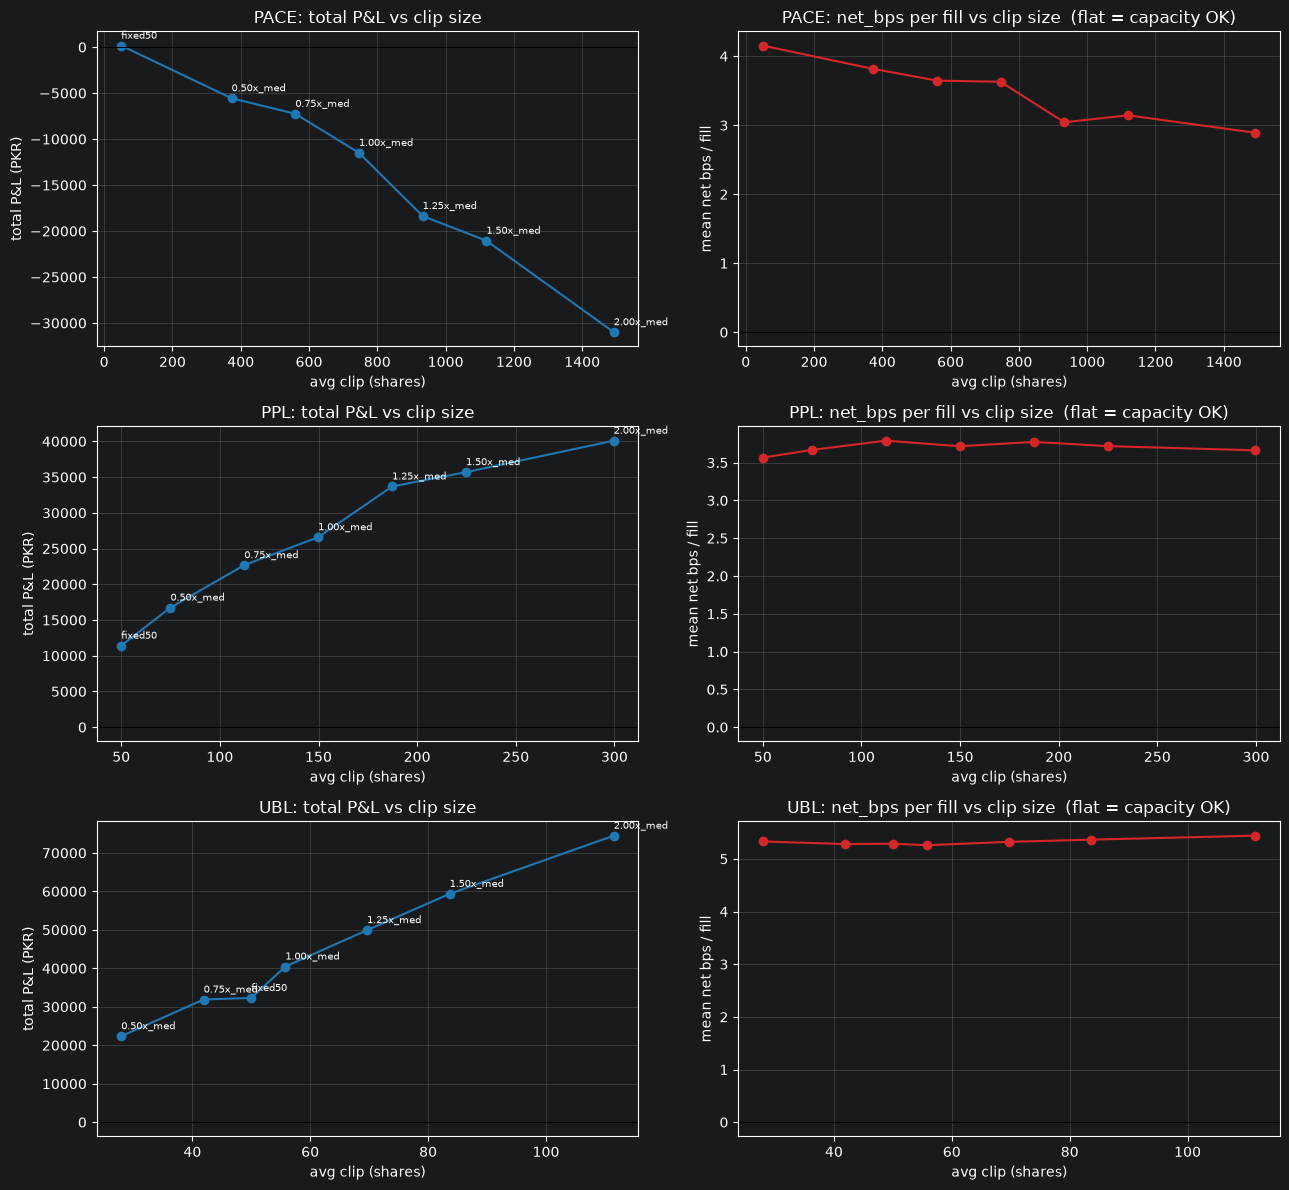

In [3]:
# ---- capacity curves: total P&L and net_bps vs avg clip, per symbol ----
# one row of two panels per symbol
syms = sorted(df.symbol.unique())
fig, axes = plt.subplots(len(syms), 2, figsize=(13, 4*len(syms)))
# handle the single-symbol case (axes would be 1-D)
if len(syms) == 1:
    axes = axes.reshape(1, 2)
# walk symbols
for i, sym in enumerate(syms):
    # this symbol's summary rows, in clip order
    sub = g[g.symbol == sym].dropna(subset=['avg_clip']).sort_values('avg_clip')
    # LEFT: total P&L vs clip
    axes[i,0].plot(sub['avg_clip'], sub['total_pnl'], 'o-', color='#1f77b4')
    # annotate each point with its config label
    for _, r in sub.iterrows():
        axes[i,0].annotate(str(r['config']), (r['avg_clip'], r['total_pnl']),
                           fontsize=7, textcoords='offset points', xytext=(0,5))
    axes[i,0].axhline(0, color='black', lw=0.8)
    axes[i,0].set_title(f'{sym}: total P&L vs clip size')
    axes[i,0].set_xlabel('avg clip (shares)'); axes[i,0].set_ylabel('total P&L (PKR)')
    axes[i,0].grid(alpha=0.3)
    # RIGHT: net_bps (per-fill quality) vs clip -- the capacity signal
    axes[i,1].plot(sub['avg_clip'], sub['net_bps'], 'o-', color='#d62728')
    axes[i,1].axhline(0, color='black', lw=0.8)
    axes[i,1].set_title(f'{sym}: net_bps per fill vs clip size  (flat = capacity OK)')
    axes[i,1].set_xlabel('avg clip (shares)'); axes[i,1].set_ylabel('mean net bps / fill')
    axes[i,1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. The trend question — is profitability steady, eroding, or expanding over the 207 days?

Cumulative P&L over calendar time for each config. A **straight rising line** is a steady edge; a line that **flattens or rolls over in recent months** is erosion; one that **steepens** is expansion. Pick the symbol below.

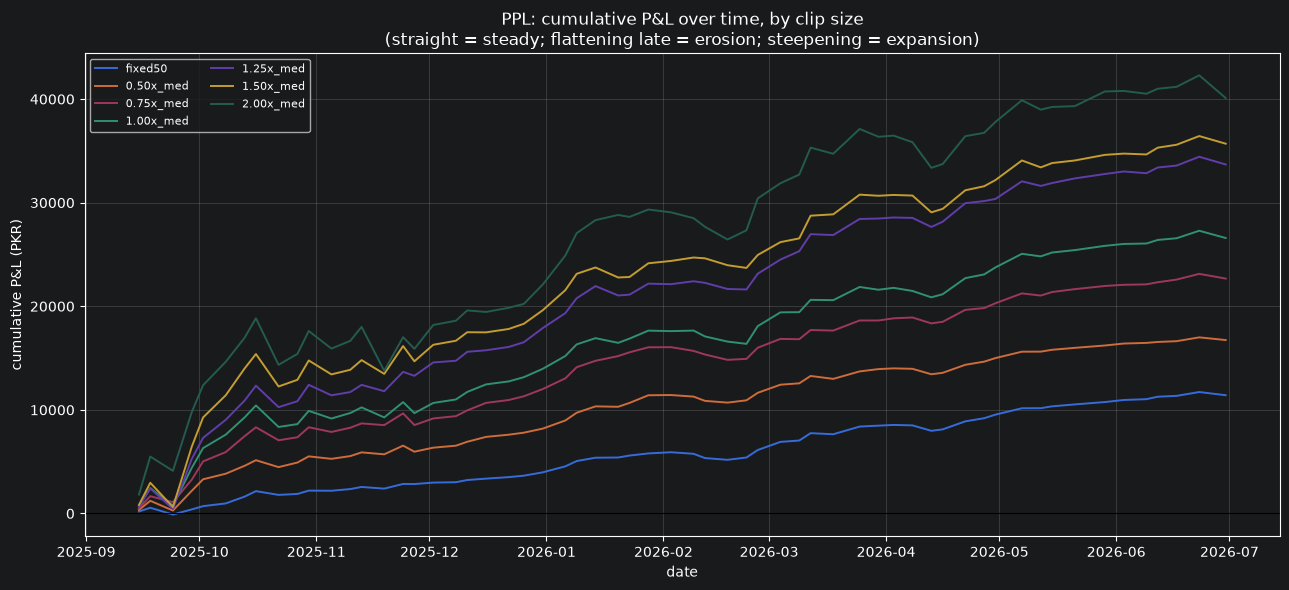

In [4]:
# ---- SYMBOL TO INSPECT (edit this one line to switch) ----
SYM = 'PPL'
# ----------------------------------------------------------
# this symbol's daily rows
d = df[df.symbol == SYM].copy()
# distinct configs present, in the readable order
cfgs = [c for c in order if c in d.config.unique()]
# cumulative-P&L figure
fig, ax = plt.subplots(figsize=(13, 6))
# a line per config
for c in cfgs:
    # this config, time-ordered
    dc = d[d.config == c].sort_values('date')
    # cumulative sum of daily P&L
    ax.plot(dc['date'], dc['pnl_pkr'].cumsum(), lw=1.4, label=c)
# zero reference
ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'{SYM}: cumulative P&L over time, by clip size\n(straight = steady; flattening late = erosion; steepening = expansion)')
ax.set_xlabel('date'); ax.set_ylabel('cumulative P&L (PKR)')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

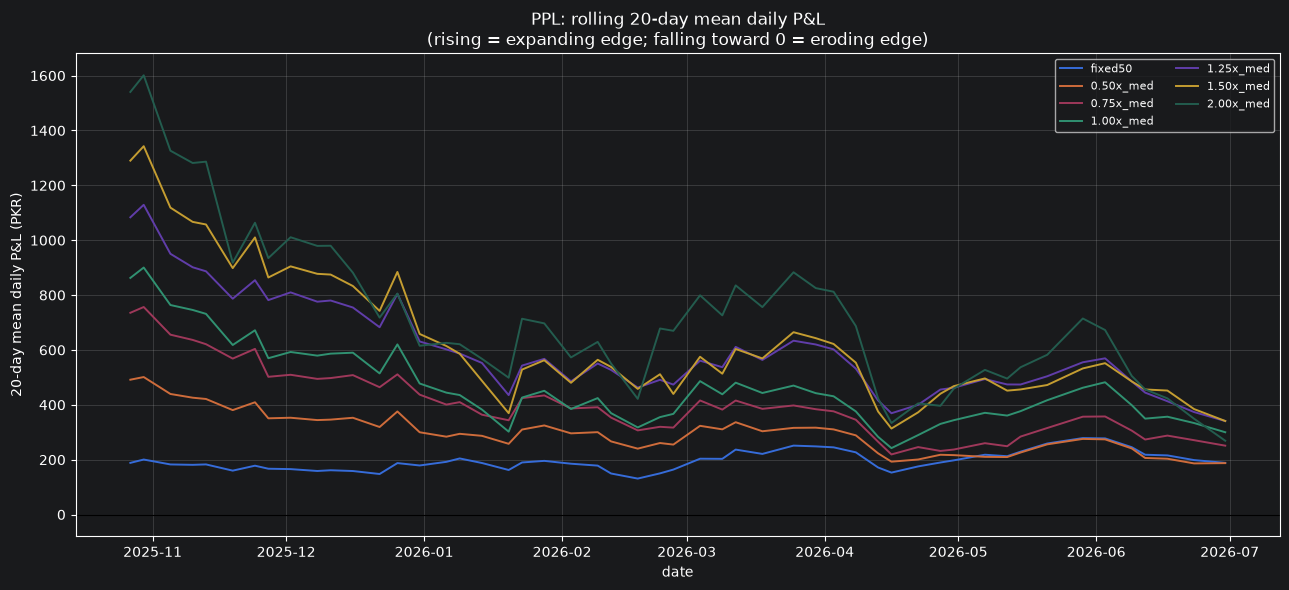

In [5]:
# ---- rolling 20-day average daily P&L: makes recent erosion/expansion explicit ----
# rolling window in trading days
WIN = 20
# figure
fig, ax = plt.subplots(figsize=(13, 6))
# a rolling line per config for the chosen symbol
for c in cfgs:
    dc = d[d.config == c].sort_values('date')
    # rolling mean of daily P&L (centered=False -> trailing, like a real-time view)
    roll = dc['pnl_pkr'].rolling(WIN, min_periods=WIN//2).mean()
    ax.plot(dc['date'], roll, lw=1.4, label=c)
ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'{SYM}: rolling {WIN}-day mean daily P&L\n(rising = expanding edge; falling toward 0 = eroding edge)')
ax.set_xlabel('date'); ax.set_ylabel(f'{WIN}-day mean daily P&L (PKR)')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. First-half vs second-half — a hard number for 'has it eroded?'

Splits each config's days in two halves by date and compares mean daily P&L and net_bps. A large drop from first to second half is erosion; a rise is expansion. This turns the eyeball read above into a number.

In [6]:
# ---- half-split table across ALL symbols/configs ----
# rows collected here
recs = []
# per symbol/config
for (sym, c), dc in df.groupby(['symbol','config']):
    # time-order
    dc = dc.sort_values('date')
    # midpoint index
    mid = len(dc) // 2
    # first and second half daily P&L
    h1 = dc.iloc[:mid]; h2 = dc.iloc[mid:]
    # skip if either half is empty
    if len(h1) == 0 or len(h2) == 0:
        continue
    # record the comparison
    recs.append({'symbol': sym, 'config': c,
                 'h1_mean_pnl': h1['pnl_pkr'].mean(),
                 'h2_mean_pnl': h2['pnl_pkr'].mean(),
                 'pnl_change_pct': (100*(h2['pnl_pkr'].mean()-h1['pnl_pkr'].mean())
                                    / abs(h1['pnl_pkr'].mean()) if h1['pnl_pkr'].mean() != 0 else np.nan),
                 'h1_net_bps': h1['net_bps'].mean(),
                 'h2_net_bps': h2['net_bps'].mean()})
# assemble + order
half = pd.DataFrame(recs)
half['config'] = pd.Categorical(half['config'], categories=order, ordered=True)
half = half.sort_values(['symbol','config'])
# show: positive pnl_change_pct = second half better (expanding); negative = eroding
half.style.format({'h1_mean_pnl':'{:,.0f}','h2_mean_pnl':'{:,.0f}',
                   'pnl_change_pct':'{:+.0f}%','h1_net_bps':'{:.3f}','h2_net_bps':'{:.3f}'})

,symbol,config,h1_mean_pnl,h2_mean_pnl,pnl_change_pct,h1_net_bps,h2_net_bps
6,PACE,fixed50,-11,17,+246%,4.525,3.784
0,PACE,0.50x_med,-301,115,+138%,4.203,3.434
1,PACE,0.75x_med,-418,177,+142%,4.266,3.029
2,PACE,1.00x_med,-593,210,+135%,4.731,2.531
3,PACE,1.25x_med,-876,263,+130%,4.101,1.986
4,PACE,1.50x_med,"-1,036",334,+132%,4.264,2.025
5,PACE,2.00x_med,"-1,414",381,+127%,4.087,1.696
13,PPL,fixed50,193,187,-3%,3.549,3.586
7,PPL,0.50x_med,380,178,-53%,3.768,3.569
8,PPL,0.75x_med,535,221,-59%,3.825,3.757


## 4. Participation vs top-of-book depth — the real-world size ceiling

P&L can say 'size up' while liquidity says 'you can't'. This shows, per config, your fill participation (% of the symbol's daily traded value) and how the clip compares to the queue you join. A clip that dwarfs top-of-book depth is a size the backtest cannot be trusted on.

In [7]:
# ---- participation + clip-vs-depth table ----
# per (symbol, config): mean participation, mean clip, and the median top-of-book
# depth (the depth columns are per-row but ~constant per symbol; take the median)
cap = df.groupby(['symbol','config']).agg(
    avg_clip=('clip_sh','mean'),
    participation_pct=('participation_pct','mean'),
    top_bid_sh=('top_bid_sh','median'),
    top_ask_sh=('top_ask_sh','median'),
).reset_index()
# clip as a MULTIPLE of the queue we join (avg of both sides)
cap['clip_vs_depth_x'] = cap['avg_clip'] / ((cap['top_bid_sh']+cap['top_ask_sh'])/2)
# order
cap['config'] = pd.Categorical(cap['config'], categories=order, ordered=True)
cap = cap.sort_values(['symbol','config'])
# show: clip_vs_depth_x > ~1 means the clip is as big or bigger than the resting
# queue -- the point where unmodeled impact/toxicity likely dominates
cap.style.format({'avg_clip':'{:,.0f}','participation_pct':'{:.3f}',
                  'top_bid_sh':'{:,.0f}','top_ask_sh':'{:,.0f}','clip_vs_depth_x':'{:.2f}x'})

,symbol,config,avg_clip,participation_pct,top_bid_sh,top_ask_sh,clip_vs_depth_x
6,PACE,fixed50,50,0.050,"3,662","3,500",0.01x
0,PACE,0.50x_med,373,0.277,"3,662","3,500",0.10x
1,PACE,0.75x_med,560,0.408,"3,662","3,500",0.16x
2,PACE,1.00x_med,746,0.532,"3,662","3,500",0.21x
3,PACE,1.25x_med,933,0.642,"3,662","3,500",0.26x
4,PACE,1.50x_med,"1,119",0.749,"3,662","3,500",0.31x
5,PACE,2.00x_med,"1,493",0.956,"3,662","3,500",0.42x
13,PPL,fixed50,50,0.048,754,"1,000",0.06x
7,PPL,0.50x_med,75,0.059,754,"1,000",0.09x
8,PPL,0.75x_med,112,0.085,754,"1,000",0.13x


### How to read all this together

1. **Capacity (§1):** the winning clip is the largest one where `net_bps` hasn't started falling — that's where marginal spread capture still beats marginal adverse selection *within what the model sees*.
2. **Trend (§2–3):** confirm the winning clip's edge is steady across the 207 days, not front-loaded. Falling rolling-P&L or a big negative half-split % = erosion; treat the headline with suspicion.
3. **Ceiling (§4):** even if P&L says size up, a `clip_vs_depth_x` well above ~1 or participation climbing past low-single-digit % means the backtest is extrapolating past what it can model. The real ceiling is the smaller of the capacity knee and the liquidity limit.

*Reminder: net_bps here is fee-inclusive per-fill P&L. The model omits market impact and size-dependent adverse selection, so large-clip results are an upper bound on true profitability, not a forecast.*